# 控制机械臂关节 Control joints

In [1]:
# 导入库  import library
import os
import ipywidgets.widgets as widgets
from IPython.display import display
import time
import threading
import cv2 as cv
from pymycobot.mycobot import MyCobot
from pymycobot.genre import Angle

In [2]:
mc = MyCobot("/dev/ttyUSB0", 1000000)
g_speed = 50

In [3]:
# 重置机械臂关节角度 reset joints
button_reset = widgets.Button(     
    description='Reset',        
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''     
    tooltip='Description',
    icon='uncheck' )

# 打开机械臂电源 Power_on
button_power_on = widgets.Button(     
    description='Power_on',        
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''     
    tooltip='Description',
    icon='uncheck' )

# 关闭机械臂电源 Power_off
button_power_off = widgets.Button(     
    description='Power_off',        
    button_style='danger', # 'success', 'info', 'warning', 'danger' or ''     
    tooltip='Description',
    icon='uncheck' )

# 按键按下事件处理   Key press event processing
def on_button_clicked(b):
    with output:
        print("Button clicked:", b.description)
    if b.description == 'Reset':
        reset_joints()
    elif b.description == 'Power_on':
        mc.power_on()
        b.icon = 'check'
        button_power_off.icon = 'uncheck'
    elif b.description == 'Power_off':
        mc.power_off()
        b.icon = 'check'
        button_power_on.icon = 'uncheck'
    
# 关联按键事件回调 Button event callbacks
button_reset.on_click(on_button_clicked)    
button_power_on.on_click(on_button_clicked)    
button_power_off.on_click(on_button_clicked)    

In [4]:
def on_slider_S1(angle):
    print("J1:", angle)
    mc.send_angle(1, angle, g_speed)
def on_slider_S2(angle):
    print("J2:", angle)
    mc.send_angle(2, angle, g_speed)
def on_slider_S3(angle):
    print("J3:", angle)
    mc.send_angle(3, angle, g_speed)
def on_slider_S4(angle):
    print("J4:", angle)
    mc.send_angle(4, angle, g_speed)
def on_slider_S5(angle):
    print("J5:", angle)
    mc.send_angle(5, angle, g_speed)
def on_slider_S6(angle):
    print("J6:", angle)
    mc.send_angle(6, angle, g_speed) 
def on_slider_S7(angle):
    print("G7:", angle)
    mc.set_gripper_value(angle, g_speed)


In [5]:
# 新建滑动条来控制舵机角度。 New sliders to control motor Angle.
slider_S1 = widgets.IntSlider(description='J1:', value=0, min=-168, max=168, step=1, orientation='horizontal')
slider_S2 = widgets.IntSlider(description='J2:', value=0, min=-135, max=90, step=1, orientation='horizontal')
slider_S3 = widgets.IntSlider(description='J3:', value=0, min=-150, max=150, step=1, orientation='horizontal')
slider_S4 = widgets.IntSlider(description='J4:', value=0 , min=-145, max=145, step=1, orientation='horizontal')
slider_S5 = widgets.IntSlider(description='J5:', value=0, min=-165, max=165, step=1, orientation='horizontal')
slider_S6 = widgets.IntSlider(description='J6:', value=-45, min=-180, max=180, step=1, orientation='horizontal')
slider_S7 = widgets.IntSlider(description='G7:', value=100 , min=30, max=100, step=1, orientation='horizontal')

widget_S1 = widgets.interactive(on_slider_S1, angle=slider_S1)
widget_S2 = widgets.interactive(on_slider_S2, angle=slider_S2)
widget_S3 = widgets.interactive(on_slider_S3, angle=slider_S3)
widget_S4 = widgets.interactive(on_slider_S4, angle=slider_S4)
widget_S5 = widgets.interactive(on_slider_S5, angle=slider_S5)
widget_S6 = widgets.interactive(on_slider_S6, angle=slider_S6)
widget_S7 = widgets.interactive(on_slider_S7, angle=slider_S7)

box_joints = widgets.VBox([widget_S7, widget_S6, widget_S5, widget_S4, widget_S3, widget_S2, widget_S1])

In [6]:
# 新建滑动条来控制运动速度。 New sliders to control speed
slider_speed = widgets.IntSlider(description='Speed:', value=50, min=1, max=100, step=1, orientation='horizontal')

def on_slider_speed(value):
    global mc, g_speed
    g_speed = value
    print("speed:", value)

widget_speed = widgets.interactive(on_slider_speed, value=slider_speed)

In [7]:
def reset_joints():
    if button_power_off.icon == 'check':
        mc.power_on()
        time.sleep(1)
    mc.send_angles([0, 0, 0, 0, 0, -45], 50)
    mc.set_gripper_value(100, 50)
    slider_S1.value = 0
    slider_S2.value = 0
    slider_S3.value = 0
    slider_S4.value = 0
    slider_S5.value = 0
    slider_S6.value = -45
    slider_S7.value = 100
    slider_speed.value = 50
    button_power_on.icon = 'check'
    button_power_off.icon = 'uncheck'
    
reset_joints()

In [8]:
imgbox = widgets.Image(format='jpg', width=640, height=480, layout=widgets.Layout(align_self='center'))
model = 'Start'

In [9]:
button_close = widgets.Button(description='Close_Camera', button_style='danger')
def button_close_Callback(value):
    global model
    model = 'Exit'
    with output: print(model)
button_close.on_click(button_close_Callback)

In [10]:
# 打开摄像头 Open camera
def camera():
    global model
    capture = cv.VideoCapture(0)
    capture.set(cv.CAP_PROP_FRAME_WIDTH, 640)
    capture.set(cv.CAP_PROP_FRAME_HEIGHT, 480)
    while capture.isOpened():
        try:
            _, img = capture.read()
            if model == 'Exit':
                break
            imgbox.value = cv.imencode('.jpg', img)[1].tobytes()
        except:
            break
    with output:
        print("capture release")
    capture.release()

In [11]:
threading.Thread(target=camera, ).start()
output = widgets.Output()
box_group1 = widgets.VBox([widget_speed, button_reset, button_power_on, button_power_off, button_close, output])
box_display = widgets.HBox([box_group1, box_joints, imgbox])
display(box_display)


[ WARN:0@2.962] global cap_gstreamer.cpp:2839 handleMessage OpenCV | GStreamer warning: Embedded video playback halted; module v4l2src0 reported: Device '/dev/video0' is busy
[ WARN:0@2.964] global cap_gstreamer.cpp:1698 open OpenCV | GStreamer warning: unable to start pipeline
[ WARN:0@2.964] global cap_gstreamer.cpp:1173 isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
[ WARN:0@2.964] global cap_v4l.cpp:999 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@2.973] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


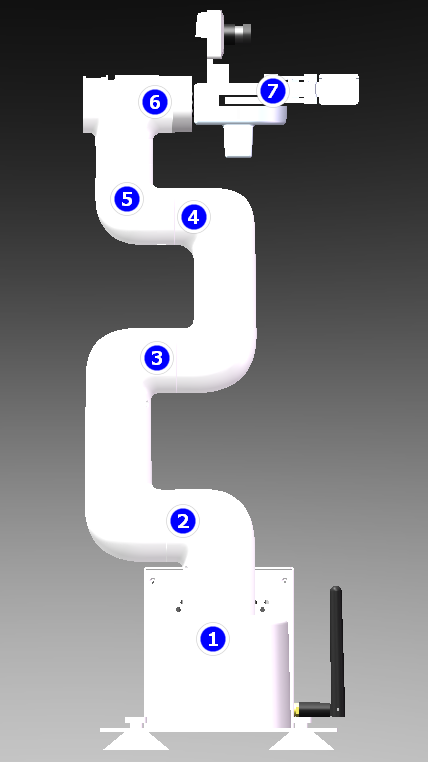